# Train Word2Vec Chapter 16 Workshop 6

## Load module

In [1]:
from gensim.models import Word2Vec
from gensim.utils  import tokenize
from gensim.parsing.preprocessing import remove_stopwords

## Setting

In [2]:
# Sentences
s1 = 'CNN is great.'
s2 = 'Python is a good language.'
s3 = 'You can learn CNN using Python.'

In [3]:
sents = s1 + s2 + s3
sents

'CNN is great.Python is a good language.You can learn CNN using Python.'

## Prepare data

In [4]:
sents = remove_stopwords(sents)
sents_tk = list(tokenize(sents, deacc=True))
sents_tk

['CNN', 'great', 'Python', 'good', 'language', 'You', 'learn', 'CNN', 'Python']

## Create and train model

In [6]:
model = Word2Vec(sentences=[sents_tk], 
                 vector_size=5, 
                 window=1, 
                 min_count=1,
                 sg=0,
                 workers=4,
                 epochs=40
                 )
# sg: 0 means CBOW, 1 means Skip-gram
# workers: number of CPU cores to use
# min count: ignore words with a total frequency lower than this value
# vector_size: size of the word vectors
print(model)

Word2Vec<vocab=7, vector_size=5, alpha=0.025>


In [7]:
for index, word in enumerate(model.wv.index_to_key):
    if index == 10:
        break
    print(f"Word {index}: {word}, Vector: {model.wv[word]}")

Word 0: Python, Vector: [-0.0108138   0.00470367  0.10220119  0.18013917 -0.18612629]
Word 1: CNN, Vector: [-0.1424493   0.12928236  0.17959216 -0.10041425 -0.07530003]
Word 2: learn, Vector: [ 0.1475618  -0.03061332 -0.09066038  0.13104187 -0.0972324 ]
Word 3: You, Vector: [-0.03639198  0.05758806  0.01992392 -0.16577223 -0.18901226]
Word 4: language, Vector: [0.14619906 0.1014197  0.13521817 0.01525299 0.12698127]
Word 5: good, Vector: [-0.06814052 -0.01889685  0.11541009 -0.1504645  -0.07873736]
Word 6: great, Vector: [-0.15022993 -0.0186024   0.19076023 -0.14638212 -0.04667447]


## Check model

In [8]:
model.wv.most_similar('good')

[('great', 0.93242347240448),
 ('CNN', 0.7743225693702698),
 ('You', 0.7670735716819763),
 ('Python', -0.00010631603072397411),
 ('language', -0.15319672226905823),
 ('learn', -0.6142301559448242)]

In [9]:
pairs = [
    ('good', 'great'),
    ('CNN', 'great'),
    ('CNN', 'good'),
    ('learn', 'Python'),
    ('language', 'You')
]
for w1, w2 in pairs:
    print(f"'{w1}' and '{w2}': {model.wv.similarity(w1, w2)}")

'good' and 'great': 0.9324235916137695
'CNN' and 'great': 0.8512625098228455
'CNN' and 'good': 0.7743225693702698
'learn' and 'Python': 0.4591066241264343
'language' and 'You': -0.34661775827407837


## Plotting

### Load module for plotting

In [10]:
import numpy as np
import matplotlib.pyplot as plt

labels = np.asarray(model.wv.index_to_key)
labels.shape

(7,)

In [19]:
print(labels)

['Python' 'CNN' 'learn' 'You' 'language' 'good' 'great']


### Check vectors

In [12]:
vectors = np.asarray(model.wv.vectors)
vectors.shape

(7, 5)

In [13]:
print(vectors.round(2))

[[-0.01  0.    0.1   0.18 -0.19]
 [-0.14  0.13  0.18 -0.1  -0.08]
 [ 0.15 -0.03 -0.09  0.13 -0.1 ]
 [-0.04  0.06  0.02 -0.17 -0.19]
 [ 0.15  0.1   0.14  0.02  0.13]
 [-0.07 -0.02  0.12 -0.15 -0.08]
 [-0.15 -0.02  0.19 -0.15 -0.05]]


### plot

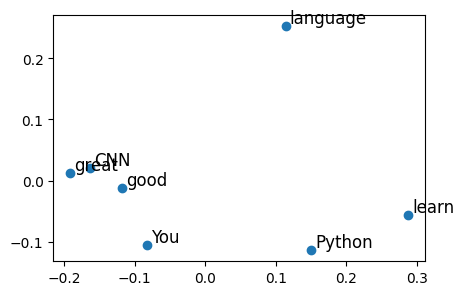

In [14]:
from sklearn.decomposition import PCA
plt.figure(figsize=(4.8, 3.2))

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)
plt.scatter(result[:, 0], result[:, 1])

for i, label in enumerate(labels):
    plt.annotate(label, (result[i, 0]+.005, result[i, 1]+.005), fontsize=12)

plt.show()

In [17]:
for i in enumerate(labels):
    print(f"{i[0]}: {i[1]}")

0: Python
1: CNN
2: learn
3: You
4: language
5: good
6: great


## Save model

In [ ]:
model.save("myword2vec.model")

## load own model

In [ ]:
trained_model = Word2Vec.load("myword2vec.model")
trained_model.wv.most_similar('Python')